# Phase 5 — Exploratory Data Analysis

Goal: Visualise the SQL findings to make business
patterns undeniable to non-technical stakeholders.

Each chart follows the analyst standard:
- Title states the insight, not the chart type
- Chart is clean and focused on one finding
- Annotation explains the business action

Charts in this notebook:
1. Overall churn distribution
2. Churn rate by contract type
3. Churn lifecycle curve by tenure group
4. Churn by payment method
5. Monthly charges vs churn behaviour

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# warnings.filterwarnings('ignore') suppresses minor
# library warnings that clutter your output but do
# not affect results — keeps notebook output clean
warnings.filterwarnings('ignore')

# Load the clean dataset — always from cleaned folder
df = pd.read_csv('../data/cleaned/telco_churn_clean.csv')

# ── VISUAL STYLE SETUP ───────────────────────────────────
# sns.set_style() sets the background style of all charts
# 'whitegrid' means white background with light grid lines
# Grid lines help readers estimate values without squinting
sns.set_style('whitegrid')

# sns.set_palette() sets the default colour sequence
# 'Set2' is a colourblind-friendly palette — important
# for professional and accessible work
sns.set_palette('Set2')

# plt.rcParams updates global chart settings
# 'figure.figsize' sets default width and height in inches
# 'axes.titlesize' sets the font size of chart titles
# 'axes.labelsize' sets the font size of axis labels
# 'xtick.labelsize' sets the font size of x-axis tick labels
# 'ytick.labelsize' sets the font size of y-axis tick labels
plt.rcParams.update({
    'figure.figsize'  : (10, 5),
    'axes.titlesize'  : 14,
    'axes.labelsize'  : 12,
    'xtick.labelsize' : 10,
    'ytick.labelsize' : 10
})

# Create the figures folder if it does not exist yet
import os
os.makedirs('../reports/figures', exist_ok=True)

print("Libraries loaded successfully")
print(f"Dataset shape : {df.shape}")
print(f"Churn rate    : {round(df['Churn'].mean()*100, 2)}%")

Libraries loaded successfully
Dataset shape : (7032, 21)
Churn rate    : 26.58%


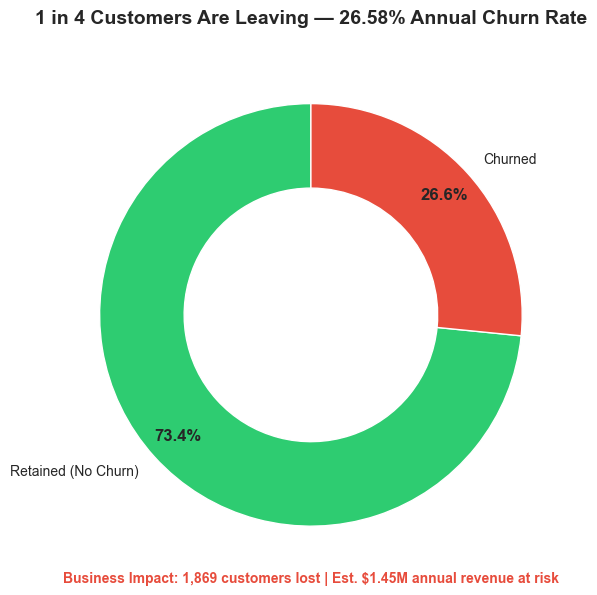

Chart 1 saved successfully


In [3]:
# ── CHART 1: OVERALL CHURN DISTRIBUTION ─────────────────
# Purpose: Show the scale of the churn problem instantly
# Audience: Executive level — needs immediate impact
# Chart type: Donut chart — cleaner than pie for proportions

# Calculate churn counts for the chart
churn_counts = df['Churn'].value_counts()

# Map 0 and 1 back to readable labels for the chart
# The model needs 0/1 but humans need words
labels = ['Retained (No Churn)', 'Churned']

# Define colours manually — red for churned (danger signal)
# green for retained (positive signal)
# Professional analysts use colour to encode meaning
colors = ['#2ecc71', '#e74c3c']

# ── BUILD THE CHART ──────────────────────────────────────
# fig, ax = plt.subplots() creates a figure and an axes
# fig is the whole canvas — like a blank page
# ax is the drawing area on that canvas
# figsize sets width and height in inches
fig, ax = plt.subplots(figsize=(8, 6))

# ax.pie() draws a pie chart on the axes
# churn_counts.values extracts the numbers [5163, 1869]
# labels assigns readable names to each slice
# colors assigns our custom colours
# autopct='%1.1f%%' adds percentage labels on each slice
#   %1.1f means: show 1 decimal place
#   the %% at the end prints a literal % sign
# startangle=90 rotates chart so it starts from the top
# pctdistance=0.85 moves percentage labels inward slightly
# wedgeprops creates the donut hole effect
#   'width':0.4 means the ring is 40% of the radius
wedges, texts, autotexts = ax.pie(
    churn_counts.values,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85,
    wedgeprops={'width': 0.4}
)

# Make the percentage text bold and white so it stands out
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

# Title states the insight — not just what the chart is
ax.set_title(
    '1 in 4 Customers Are Leaving — 26.58% Annual Churn Rate',
    fontweight='bold',
    pad=20
)

# Add a text annotation below the chart explaining the
# business impact — this is what makes it intelligence
# not just a visualisation
fig.text(
    0.5, 0.02,
    'Business Impact: 1,869 customers lost | Est. $1.45M annual revenue at risk',
    ha='center',
    fontsize=10,
    color='#e74c3c',
    fontweight='bold'
)

# plt.tight_layout() automatically adjusts spacing
# so nothing overlaps or gets cut off
plt.tight_layout()

# Save the figure to reports/figures folder
# dpi=150 sets resolution — 150 is good for reports
# bbox_inches='tight' ensures nothing is cropped
plt.savefig('../reports/figures/01_churn_overview.png',
            dpi=150, bbox_inches='tight')

plt.show()
print("Chart 1 saved successfully")

Contract churn rates:
         Contract  Churn Rate (%)
0  Month-to-month           42.71
1        One year           11.28
2        Two year            2.85


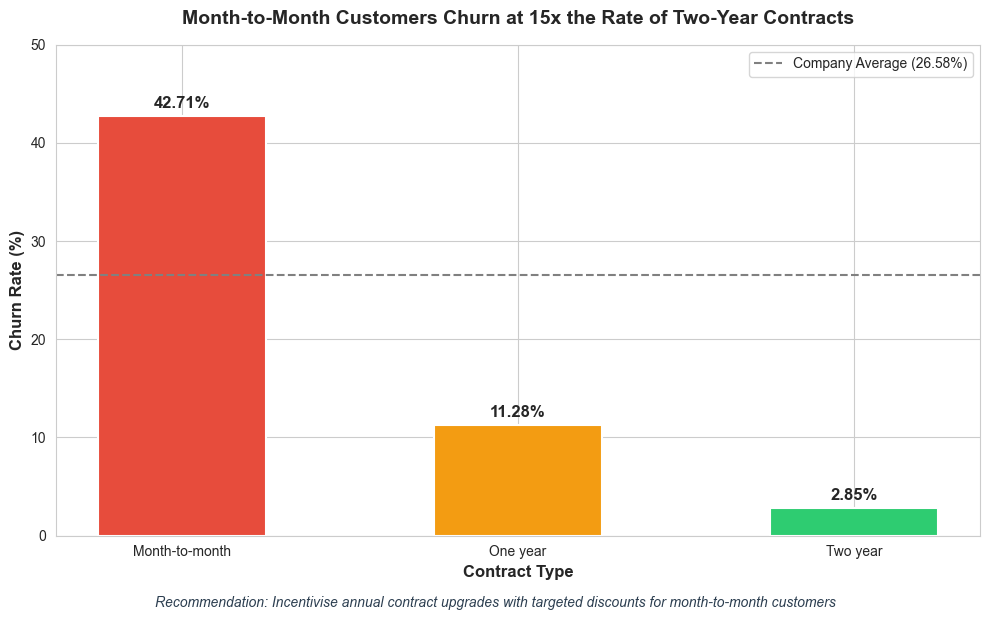

Chart 2 saved successfully


In [4]:
# ── CHART 2: CHURN BY CONTRACT TYPE ─────────────────────
# Purpose: Show the 15x gap between contract types
# This is the single most actionable finding in the data

# Calculate churn rate per contract type
# We use the same logic as our SQL Q2 query
# groupby groups rows by Contract value
# ['Churn'].mean() calculates average churn per group
# Since Churn is 0/1, mean = proportion = churn rate
# multiply by 100 to get percentage
# reset_index() converts the result back to a DataFrame
contract_churn = (
    df.groupby('Contract')['Churn']
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
)

# Rename columns to be more readable
# columns= takes a list of new names in order
contract_churn.columns = ['Contract', 'Churn Rate (%)']

# Sort by churn rate descending so highest bar is first
contract_churn = contract_churn.sort_values(
    'Churn Rate (%)', ascending=False
)

print("Contract churn rates:")
print(contract_churn)

# ── BUILD THE CHART ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# Define colours — red for highest risk, amber for medium
# green for lowest risk — traffic light colour logic
# This colour encoding helps readers understand risk
# without reading the numbers
bar_colors = ['#e74c3c', '#f39c12', '#2ecc71']

# ax.bar() draws a vertical bar chart
# contract_churn['Contract'] is the x-axis categories
# contract_churn['Churn Rate (%)'] is the bar heights
# color assigns our custom colours to each bar
# width=0.5 makes bars slightly narrower than default
# edgecolor='white' adds a white border around bars
bars = ax.bar(
    contract_churn['Contract'],
    contract_churn['Churn Rate (%)'],
    color=bar_colors,
    width=0.5,
    edgecolor='white',
    linewidth=1.5
)

# Add value labels on top of each bar
# This saves the reader from estimating from the y-axis
for bar in bars:
    # bar.get_height() returns the height of this bar
    height = bar.get_height()
    
    # ax.text() places text on the chart at x,y coordinates
    # bar.get_x() + bar.get_width()/2 centers the label
    # height + 0.5 places it just above the bar top
    # f'{height}%' formats the label with a % sign
    # ha='center' means horizontally centred
    # va='bottom' means anchored to the bottom of the text
    # fontweight='bold' makes label easy to read
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{height}%',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=12
    )

# Add a horizontal dashed line showing the average
# This gives readers context — above line = worse than avg
ax.axhline(
    y=26.58,
    color='gray',
    linestyle='--',
    linewidth=1.5,
    label='Company Average (26.58%)'
)

# ax.legend() adds the legend for the dashed line
ax.legend(fontsize=10)

# Label the axes clearly
ax.set_xlabel('Contract Type', fontweight='bold')
ax.set_ylabel('Churn Rate (%)', fontweight='bold')

# Title states the insight
ax.set_title(
    'Month-to-Month Customers Churn at 15x the Rate of Two-Year Contracts',
    fontweight='bold',
    pad=15
)

# Set y-axis to start at 0 and go to 50
# gives visual breathing room above highest bar
ax.set_ylim(0, 50)

# Add annotation explaining the business action
fig.text(
    0.5, -0.02,
    'Recommendation: Incentivise annual contract upgrades '
    'with targeted discounts for month-to-month customers',
    ha='center',
    fontsize=10,
    color='#2c3e50',
    style='italic'
)

plt.tight_layout()
plt.savefig('../reports/figures/02_churn_by_contract.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved successfully")

Tenure churn rates:
            Tenure Group  Churn Rate (%)
0           New\n(0-12m)           47.68
1   Developing\n(13-24m)           28.71
2  Established\n(25-48m)           20.39
3        Loyal\n(49-72m)            9.51

Payment churn rates:
          Payment Method  Churn Rate (%)
0    Credit card\n(auto)           15.25
1  Bank transfer\n(auto)           16.73
2           Mailed check           19.20
3       Electronic check           45.29


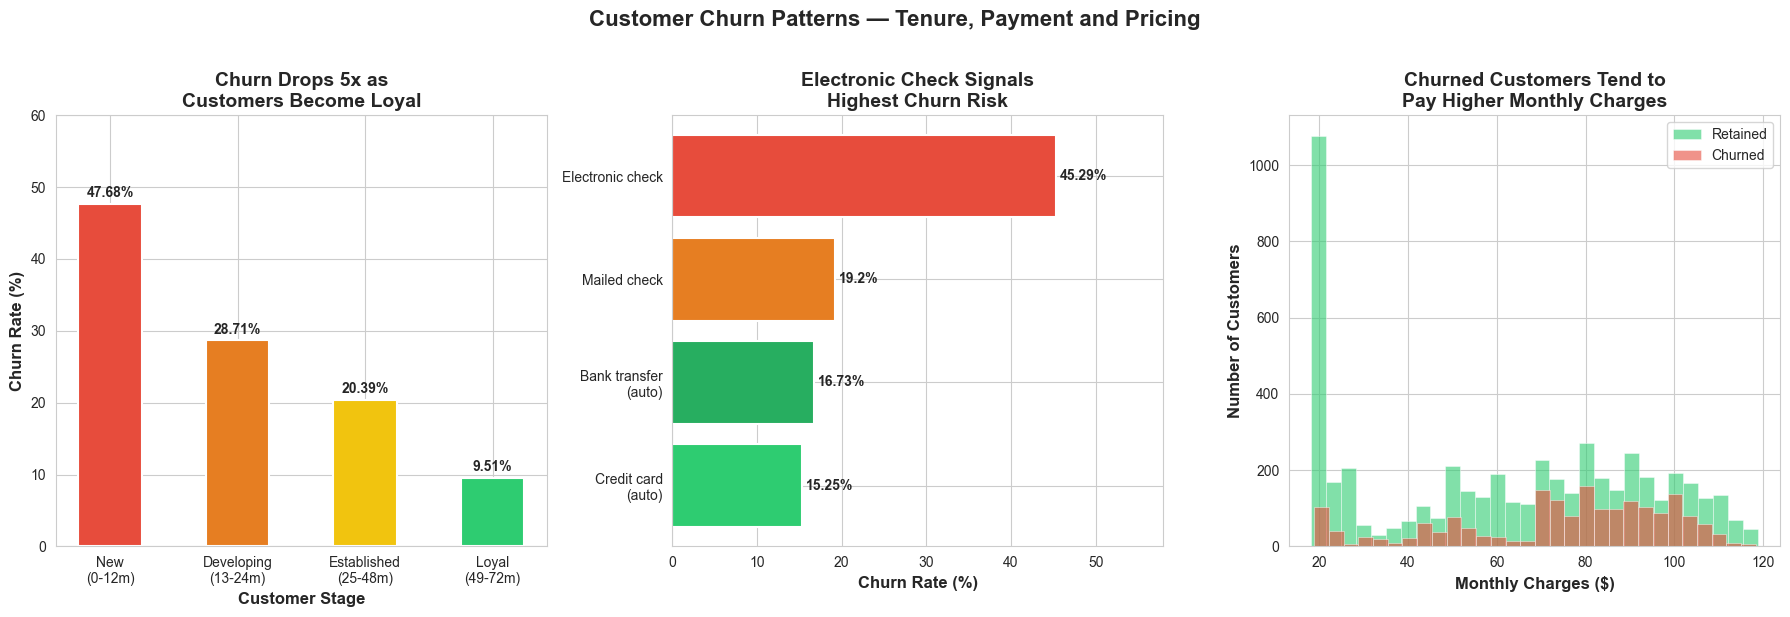

Charts 3, 4 and 5 saved successfully


In [6]:
# ── CHARTS 3, 4, 5: TENURE + PAYMENT + CHARGES ──────────

import os
os.makedirs('../reports/figures', exist_ok=True)

# ── PREPARE DATA — TENURE GROUPS ─────────────────────────

# pd.cut() slices a continuous number column into labelled
# categories based on boundary points we define
# bins=[0,12,24,48,72] creates 4 ranges:
#   0-12, 13-24, 25-48, 49-72
# labels= assigns a readable name to each range
# observed=True suppresses a pandas warning about
# categorical groupby operations
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=[
        'New\n(0-12m)',
        'Developing\n(13-24m)',
        'Established\n(25-48m)',
        'Loyal\n(49-72m)'
    ],
    right=True
)

# Calculate churn rate per tenure group
# groupby groups all rows that share the same tenure_group
# ['Churn'].mean() gets the average of 0s and 1s per group
# which equals the churn proportion per group
# .mul(100) converts proportion to percentage
# .round(2) keeps 2 decimal places
# .reset_index() converts grouped result back to DataFrame
tenure_churn = (
    df.groupby('tenure_group', observed=True)['Churn']
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
)

# Rename columns to readable names
tenure_churn.columns = ['Tenure Group', 'Churn Rate (%)']
print("Tenure churn rates:")
print(tenure_churn)

# ── PREPARE DATA — PAYMENT METHOD ────────────────────────

# Same groupby logic as tenure but grouped by PaymentMethod
payment_churn = (
    df.groupby('PaymentMethod')['Churn']
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
)

# Rename columns FIRST before sorting
# This is the fix — sort must happen AFTER rename
# otherwise the column name 'Churn Rate (%)' does not
# exist yet and pandas throws a KeyError
payment_churn.columns = ['Payment Method', 'Churn Rate (%)']

# Now sort — column name exists so no error
payment_churn = payment_churn.sort_values(
    'Churn Rate (%)', ascending=True
).reset_index(drop=True)

# Shorten long payment method names for chart readability
# .str.replace() finds a substring and replaces it
# regex=False means treat it as plain text not a pattern
payment_churn['Payment Method'] = (
    payment_churn['Payment Method']
    .str.replace(' (automatic)', '\n(auto)', regex=False)
)

print("\nPayment churn rates:")
print(payment_churn)

# ── BUILD THE 3-PANEL FIGURE ─────────────────────────────

# plt.subplots(1,3) creates a grid of 1 row and 3 columns
# figsize=(18,6) sets overall figure width=18 height=6 inches
# axes is returned as a list of 3 individual chart areas
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Unpack the list into three named variables
# This makes the code below more readable than axes[0], axes[1]
ax1, ax2, ax3 = axes

# ── CHART 3: TENURE LIFECYCLE CURVE ──────────────────────
# Traffic light colour logic — red=danger, green=safe
# Each bar gets its own colour based on risk level
colors_tenure = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']

# ax1.bar() draws vertical bars on the first chart area
# tenure_churn['Tenure Group'] = x axis labels
# tenure_churn['Churn Rate (%)'] = bar heights
# color= assigns one colour per bar from our list
# width=0.5 makes bars slightly narrower than default
# edgecolor='white' adds white border between bars
bars3 = ax1.bar(
    tenure_churn['Tenure Group'],
    tenure_churn['Churn Rate (%)'],
    color=colors_tenure,
    width=0.5,
    edgecolor='white',
    linewidth=1.5
)

# Add value labels on top of each bar
# We loop through each bar object in the chart
for bar in bars3:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{height}%',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=10
    )

# Set title as business insight not chart description
ax1.set_title(
    'Churn Drops 5x as\nCustomers Become Loyal',
    fontweight='bold'
)
ax1.set_xlabel('Customer Stage', fontweight='bold')
ax1.set_ylabel('Churn Rate (%)', fontweight='bold')
ax1.set_ylim(0, 60)

# ── CHART 4: PAYMENT METHOD ──────────────────────────────
# barh() draws horizontal bars — better for long labels
# Same logic as bar() but x and y axes are swapped
colors_payment = ['#2ecc71', '#27ae60', '#e67e22', '#e74c3c']

bars4 = ax2.barh(
    payment_churn['Payment Method'],
    payment_churn['Churn Rate (%)'],
    color=colors_payment,
    edgecolor='white',
    linewidth=1.5
)

# Add value labels to the right of each horizontal bar
# For horizontal bars we use bar.get_width() not get_height()
# because the value is represented by bar width not height
for bar in bars4:
    width = bar.get_width()
    ax2.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{width}%',
        ha='left',
        va='center',
        fontweight='bold',
        fontsize=10
    )

ax2.set_title(
    'Electronic Check Signals\nHighest Churn Risk',
    fontweight='bold'
)
ax2.set_xlabel('Churn Rate (%)', fontweight='bold')
ax2.set_xlim(0, 58)

# ── CHART 5: MONTHLY CHARGES DISTRIBUTION ────────────────
# Two overlapping histograms on the same chart area
# One for churned customers and one for retained customers
# This reveals whether price is connected to churn

# df[df['Churn']==0] filters rows where Churn equals 0
# This gives us only retained customer rows
# ['MonthlyCharges'] selects just that one column
# bins=30 divides the charge range into 30 equal buckets
# alpha=0.6 makes bars 60% opaque so both groups visible
# when they overlap each other
ax3.hist(
    df[df['Churn'] == 0]['MonthlyCharges'],
    bins=30,
    alpha=0.6,
    color='#2ecc71',
    label='Retained',
    edgecolor='white',
    linewidth=0.5
)

# Same for churned customers — red bars
# Because alpha=0.6 on both, where they overlap
# you see a blend of both colours
ax3.hist(
    df[df['Churn'] == 1]['MonthlyCharges'],
    bins=30,
    alpha=0.6,
    color='#e74c3c',
    label='Churned',
    edgecolor='white',
    linewidth=0.5
)

ax3.set_title(
    'Churned Customers Tend to\nPay Higher Monthly Charges',
    fontweight='bold'
)
ax3.set_xlabel('Monthly Charges ($)', fontweight='bold')
ax3.set_ylabel('Number of Customers', fontweight='bold')

# ax3.legend() adds the colour key to the chart
# so readers know which colour means churned vs retained
ax3.legend(fontsize=10)

# ── SHARED TITLE ACROSS ALL THREE CHARTS ─────────────────
# fig.suptitle() adds one title above all three charts
# y=1.02 pushes it slightly above the chart area
# so it does not overlap with individual chart titles
fig.suptitle(
    'Customer Churn Patterns — Tenure, Payment and Pricing',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

# tight_layout() automatically adjusts spacing between
# the three charts so nothing overlaps or gets cut off
plt.tight_layout()

plt.savefig(
    '../reports/figures/03_churn_patterns.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()
print("Charts 3, 4 and 5 saved successfully")

## Chart 5 Finding — Premium Price Churn Risk

### What the chart shows
Churned customers concentrate in the $80–100/month range.
Retained customers spread across all price points but
dominate the low $18–25/month segment overwhelmingly.

### Business interpretation
Premium customers paying $80–100/month are not perceiving
sufficient value to justify spending $960–1,200 annually.
Low-price customers at $18–25/month rarely churn because
their expectations are calibrated to a lower price point
and their switching cost calculation is simpler.

### Why this is dangerous at the KPI level
Our LTV:CAC ratio is 0.82:1 — meaning we lose $54 on
every customer we acquire. Premium customers who churn
fast represent the worst possible outcome:
high acquisition cost + short tenure + high monthly charge
= maximum financial damage per customer lost.

### Business action
Identify customers paying $80+ with tenure under 12 months.
These are the intersection of premium pricing and high
churn risk — the most expensive customers to lose.
Priority action: proactive customer success outreach
within first 90 days for all customers on $80+ plans.
Demonstrate premium feature value before they question it.